Goal: Determine the best month to buy pumkins
  1. the average price of pumkins for each year

In [180]:
import pandas as pd
import numpy as np

#loading the data
pumpkins = pd.read_csv('/workspaces/ML-For-Beginners/2-Regression/data/US-pumpkins.csv')
pumpkins.head(15)

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
5,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/12/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
6,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,170.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
7,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
8,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,10/1/16,160.0,170.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
9,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,10/1/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [181]:
#filtering out rows that dont use pric per bushel
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case = True, regex = True)]
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [182]:
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [183]:
relevant_columns = ['Package', 'Month','Low Price', 'High Price', 'Date']
pumpkins = pumpkins.drop([c for c in pumpkins.columns if c not in relevant_columns], axis = 1)

In [184]:
#calculating the average price from the high and low proce colums
pumpkins['Price'] = (pumpkins['Low Price'] + pumpkins['High Price'])/2

In [185]:
#Get the month from the date column
pumpkins['Month'] = pd.DatetimeIndex(pumpkins['Date']).month

In [186]:

#pumpkins = pumpkins.drop(['Low Price', 'High Price'], axis = 1)
pumpkins.columns


Index(['Package', 'Date', 'Low Price', 'High Price', 'Price', 'Month'], dtype='object')

In [187]:
pumpkins

,Package,Date,Low Price,High Price,Price,Month
70,1 1/9 bushel cartons,9/24/16,15.00,15.0,15.000,9
71,1 1/9 bushel cartons,9/24/16,18.00,18.0,18.000,9
72,1 1/9 bushel cartons,10/1/16,18.00,18.0,18.000,10
73,1 1/9 bushel cartons,10/1/16,17.00,17.0,17.000,10
74,1 1/9 bushel cartons,10/8/16,15.00,15.0,15.000,10
...,...,...,...,...,...,...
1738,1/2 bushel cartons,9/30/16,15.00,15.0,15.000,9
1739,1/2 bushel cartons,9/30/16,13.75,15.0,14.375,9
1740,1/2 bushel cartons,9/30/16,10.75,15.0,12.875,9
1741,1/2 bushel cartons,9/30/16,12.00,12.0,12.000,9


In [188]:
#There are two quanttiies of packaging, 1 1/2 bushel cartons and 1 1/9 bushel cartons
# I will normalize them (make the price for both the price for 1 bushel cartons)
pumpkins['Normalized Price'] = pumpkins['Price']

pumpkins.loc[pumpkins['Package'].str.contains('1 1/9'), 'Normalized Price'] = pumpkins['Price'] / (10/9)

pumpkins.loc[pumpkins['Package'].str.contains('1/2'), 'Normalized Price'] = pumpkins['Price'] / 0.5

In [189]:
pumpkins.head()

,Package,Date,Low Price,High Price,Price,Month,Normalized Price
70,1 1/9 bushel cartons,9/24/16,15.0,15.0,15.0,9,13.5
71,1 1/9 bushel cartons,9/24/16,18.0,18.0,18.0,9,16.2
72,1 1/9 bushel cartons,10/1/16,18.0,18.0,18.0,10,16.2
73,1 1/9 bushel cartons,10/1/16,17.0,17.0,17.0,10,15.3
74,1 1/9 bushel cartons,10/8/16,15.0,15.0,15.0,10,13.5


In [190]:
pumpkins.tail()

,Package,Date,Low Price,High Price,Price,Month,Normalized Price
1738,1/2 bushel cartons,9/30/16,15.00,15.0,15.000,9,30.00
1739,1/2 bushel cartons,9/30/16,13.75,15.0,14.375,9,28.75
1740,1/2 bushel cartons,9/30/16,10.75,15.0,12.875,9,25.75
1741,1/2 bushel cartons,9/30/16,12.00,12.0,12.000,9,24.00
1742,1/2 bushel cartons,9/30/16,12.00,12.0,12.000,9,24.00


In [194]:
pumpkins['Normalized Price'].isnull().sum()



np.int64(0)

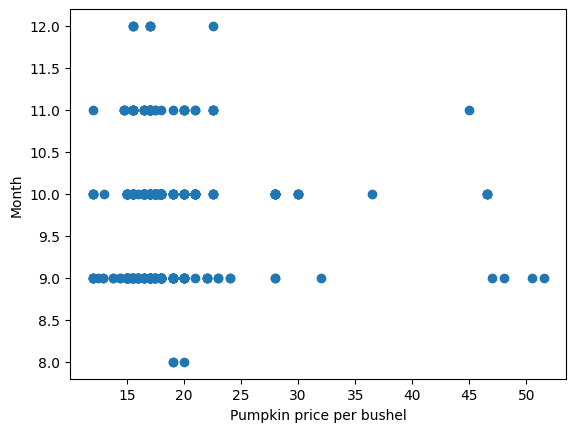

In [192]:
import matplotlib.pyplot as plt

plt.scatter(pumpkins['Price'] ,pumpkins['Month'])
plt.xlabel('Pumpkin price per bushel')
plt.ylabel('Month')
plt.show()


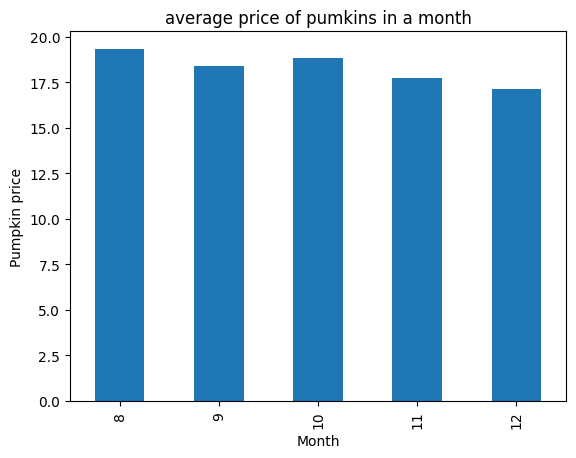

In [ ]:
#using a bar chart/ histogram to visulize the data

#grouping the pumins into a bar hrat by month and price
pumpkins.groupby(['Month'])['Price'].mean().plot(kind = 'bar')

plt.ylabel('Pumpkin price')
plt.title('average price of pumkins in a month')
plt.show()

In [195]:
#The above graph shows that the cheapest month to buy pumpkins is in December